# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nfl_data_py as nfl

from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import KFold
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import ParameterSampler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import xgboost as xgb
import shap
import optuna

from ELO import ELO

/Users/iggysiegel/opt/anaconda3/envs/sports_betting/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Import Data

In [2]:
data = pd.read_csv("data/data_engineering_2008_2024_15.csv")
data = data[data["season"] != 2010] # Drop first season due to data engineering

/var/folders/4p/33lbnggs2vz1ffh9zv619nnm0000gn/T/ipykernel_54952/149168617.py:1: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/data_engineering_2008_2024_15.csv")


In [3]:
features = [
    # General
    'home_elo_prob',
    'div_game',
    'is_playoff',
    'week',
    'away_rest',
    'home_rest',

    # Offense - Home
    'current_win_pctg_home',
    'last_win_pctg_home',
    'streak_home',
    'ats_pctg_home',
    'spread_differential_home',
    'drive_scoring_percentage_off_home',
    'qbr_home',
    'posteam_score_max_off_home',
    'yards_gained_sum_off_home',
    'total_time_of_posession_off_home',
    'total_plays_off_home',
    'complete_pass_sum_off_home',
    'passing_yards_sum_off_home',
    'pass_touchdown_sum_off_home',
    'rush_attempt_sum_off_home',
    'rushing_yards_sum_off_home',
    'rush_touchdown_sum_off_home',
    'third_down_conversion_rate_off_home',
    'penalty_yards_sum_off_home',
    'fumble_lost_sum_off_home',
    'net_turnovers_off_home',
    'qb_hit_sum_off_home',
    'sack_sum_off_home',
    'epa_sum_off_home',

    # Defense - Home
    'posteam_score_max_def_home',
    'yards_gained_sum_def_home',
    'total_plays_def_home',
    'fumble_lost_sum_def_home',
    'net_turnovers_def_home',
    'third_down_conversion_rate_def_home',
    'passing_yards_sum_def_home',
    'pass_touchdown_sum_def_home',
    'rushing_yards_sum_def_home',
    'rush_touchdown_sum_def_home',
    'qb_hit_sum_def_home',
    'sack_sum_def_home',
    'epa_sum_def_home',

    # Offense - Away
    'current_win_pctg_away',
    'last_win_pctg_away',
    'streak_away',
    'ats_pctg_away',
    'spread_differential_away',
    'drive_scoring_percentage_off_away',
    'qbr_away',
    'posteam_score_max_off_away',
    'yards_gained_sum_off_away',
    'total_time_of_posession_off_away',
    'total_plays_off_away',
    'complete_pass_sum_off_away',
    'passing_yards_sum_off_away',
    'pass_touchdown_sum_off_away',
    'rush_attempt_sum_off_away',
    'rushing_yards_sum_off_away',
    'rush_touchdown_sum_off_away',
    'third_down_conversion_rate_off_away',
    'penalty_yards_sum_off_away',
    'fumble_lost_sum_off_away',
    'net_turnovers_off_away',
    'qb_hit_sum_off_away',
    'sack_sum_off_away',
    'epa_sum_off_away',

    # Defense - Away
    'posteam_score_max_def_away',
    'yards_gained_sum_def_away',
    'total_plays_def_away',
    'fumble_lost_sum_def_away',
    'net_turnovers_def_away',
    'third_down_conversion_rate_def_away',
    'passing_yards_sum_def_away',
    'pass_touchdown_sum_def_away',
    'rushing_yards_sum_def_away',
    'rush_touchdown_sum_def_away',
    'qb_hit_sum_def_away',
    'sack_sum_def_away',
    'epa_sum_def_away'
]

# XGBoost / Hyperparameter Tuning

In [4]:
def prepare_data(data, train_seasons, test_seasons, features):
    """
    Prepare data for training and testing.

    Inputs:
        - data: pd.DataFrame, data
        - features: list, features to use
        - train_seasons: list, seasons to train on
        - test_seasons: list, seasons to test on
    Outputs:
        - train_data: pd.DataFrame, training data
        - test_data: pd.DataFrame, testing data
        - X_train: pd.DataFrame, training features
        - y_train: pd.Series, training labels
        - X_test: pd.DataFrame, testing features
        - y_test: pd.Series, testing labels
    """
    train_data = data[data["season"].isin(train_seasons)].dropna(subset = features)
    test_data = data[data["season"].isin(test_seasons)].dropna(subset = features)
    
    X_train = train_data[features]
    y_train = train_data["total_line"]
    X_test = test_data[features]
    y_test = test_data["total_line"]

    return train_data, test_data, X_train, y_train, X_test, y_test

In [5]:
def objective(trial, X_train, y_train):
    """
    Objective function for Optuna to optimize XGBoost hyperparameters for regression.

    Inputs:
        - trial: Optuna trial object
        - X_train: pd.DataFrame, Input features
        - y_train: pd.Series, Continuous target labels
    Outputs:
        - score: float, Validation RMSE score
    """
    # Define the hyperparameter search space
    param_grid = {
        "max_depth": trial.suggest_int("max_depth", 1, 5),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "learning_rate": trial.suggest_float("learning_rate", 0.0001, 0.1),
        "reg_alpha": trial.suggest_categorical("reg_alpha", [0.0, 0.1, 0.5, 1.0]),
        "reg_lambda": trial.suggest_categorical("reg_lambda", [0.0, 0.1, 0.5, 1.0, 5.0])
    }

    # Initialize the XGBoost model for regression
    model = xgb.XGBRegressor(
        objective = "reg:squarederror",
        eval_metric = "rmse",
        n_estimators = 10000,
        early_stopping_rounds = 10,
        **param_grid
    )

    # 5-fold cross validation
    kf = KFold(n_splits = 5)
    scores = []
    early_stopping = []
    for train_index, val_index in kf.split(X_train):
        X_t, X_v = X_train.iloc[train_index], X_train.iloc[val_index]
        y_t, y_v = y_train.iloc[train_index], y_train.iloc[val_index]
        model.fit(
            X_t,
            y_t,
            eval_set = [(X_v, y_v)],
            verbose = False
        )
        preds = model.predict(X_v)
        scores.append(metrics.root_mean_squared_error(y_v, preds))
        early_stopping.append(model.best_iteration)
    trial.set_user_attr("early_stopping", int(sum(early_stopping) / len(early_stopping)))

    # Return the mean validation RMSE
    return sum(scores) / len(scores)

In [6]:
def tune_hyperparameters(X_train, y_train, n_trials):
    """
    Run Optuna hyperparameter tuning.

    Inputs:
        - X_train: pd.DataFrame, Input features
        - y_train: pd.Series, Input labels
        - n_trials: int, Number of optimization trials
    Output:
        - study: Optuna study object
    """
    study = optuna.create_study(direction = "minimize")
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials = n_trials)
    return study

In [7]:
def betting_simulation(train_data, test_data, confidence = 1.0):
    """ 
    Simulate betting on games based on model predictions.

    Inputs:
        - train_data: pd.DataFrame, training data
        - test_data: pd.DataFrame, testing data
        - confidence: float, number of standard deviations to define high-confidence bets (default is 1.0)
    Outputs:
        - overall_accuracy: float, overall accuracy of betting strategy
        - total_games: int, total number of games bet on
        
    The function evaluates betting outcomes by comparing model predictions to the spread lines. If the 
    difference between the model predictions and spread lines is greater than the threshold, the function
    bets on the game.
    """
    # Determine threshold for high-confidence bets
    threshold = confidence * np.std(train_data["difference"])

    # Initialize counters
    num_correct_total = 0
    num_incorrect_total = 0
    
    # Iterate through each week
    for week in test_data["week"].unique():
        week_data = test_data[test_data["week"] == week]
        num_correct_week = 0
        num_incorrect_week = 0
        for row in week_data.itertuples():
            if row.difference > threshold:
                if (
                    (row.predictions < row.total_line and (row.home_score + row.away_score) < row.total_line) or
                    (row.predictions > row.total_line and (row.home_score + row.away_score) > row.total_line)
                ):                    
                    num_correct_week += 1
                    num_correct_total += 1
                else:
                    num_incorrect_week += 1
                    num_incorrect_total += 1

        # Calculate and print weekly accuracy
        total_week_games = num_correct_week + num_incorrect_week
        if total_week_games > 0:
            weekly_accuracy = num_correct_week / total_week_games
            print(f"Week {week:<2}: {weekly_accuracy:.4f} ({num_correct_week}/{total_week_games})")

    # Calculate and print overall accuracy
    total_games = num_correct_total + num_incorrect_total
    if total_games > 0:
        overall_accuracy = num_correct_total / total_games
        print(f"\nSeason Accuracy: {overall_accuracy:.4f} ({num_correct_total}/{total_games})")

    return overall_accuracy, total_games

In [8]:
def main(data, train_seasons, test_seasons, features, n_trials = 100, confidence = 1.0, shapley = False):
    """ 
    Main function to train a machine learning model for NFL game predictions.

    This function prepares the data, tunes hyperparameters, trains the model, and simulates betting outcomes
    based on the model's predictions.

    Inputs:
        - data: pd.DataFrame, full dataset containing game data
        - train_seasons: list, seasons used for training the model
        - test_seasons: list, seasons used for testing the model
        - features: list, feature columns used for model training and predictions
        - n_trials: int, number of trials for hyperparameter optimization (default is 100)
        - confidence: float, number of standard deviations to define high-confidence bets (default is 1.0)
        - shapley: bool, whether to plot SHAP values (default is False)
    Outputs:
        - train_data: pd.DataFrame, training data with model predictions
        - test_data: pd.DataFrame, testing data with model predictions
        - model: Fit XGBoost model
    """
    # Prepare data
    train_data, test_data, X_train, y_train, X_test, y_test = prepare_data(data, train_seasons, test_seasons, features)

    # Tune hyperparameters
    study = tune_hyperparameters(X_train, y_train, n_trials)
    print("Best Optuna parameters:", study.best_params)
    print("Best Optuna score:", study.best_value)
    print()

    # Fit the model with the best hyperparameters
    model = xgb.XGBRegressor(
        objective = "reg:squarederror",
        eval_metric = "rmse",
        n_estimators = study.best_trial.user_attrs["early_stopping"],
        **study.best_params
    )
    model.fit(X_train, y_train)

    # Store predictions and differences
    train_data["predictions"] = model.predict(X_train)
    train_data["difference"] = abs(train_data["predictions"] - train_data["total_line"])
    test_data["predictions"] = model.predict(X_test)
    test_data["difference"] = abs(test_data["predictions"] - test_data["total_line"])

    # Shapley plot
    if shapley:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_train)
        plt.figure(figsize = (20, 12))
        shap.summary_plot(shap_values, X_train, show = True, max_display = 20, plot_type = "violin")
        plt.show()

    # Betting simulation
    _, _ = betting_simulation(train_data, test_data, confidence)

    return train_data, test_data, model

# Performance

In [9]:
N_TRIALS = 100
CONFIDENCE = 2.0

[I 2024-12-27 13:40:27,989] A new study created in memory with name: no-name-c870dc0b-5a7e-4e35-8363-8ee2258b531a
[I 2024-12-27 13:40:32,277] Trial 0 finished with value: 2.480971656882607 and parameters: {'max_depth': 1, 'subsample': 0.9301879121760017, 'colsample_bytree': 0.9262151289579195, 'learning_rate': 0.04300419352057895, 'reg_alpha': 0.0, 'reg_lambda': 1.0}. Best is trial 0 with value: 2.480971656882607.
[I 2024-12-27 13:40:34,200] Trial 1 finished with value: 2.4797561815123688 and parameters: {'max_depth': 4, 'subsample': 0.8417086044360598, 'colsample_bytree': 0.6008744101389132, 'learning_rate': 0.07536589066054387, 'reg_alpha': 1.0, 'reg_lambda': 0.0}. Best is trial 1 with value: 2.4797561815123688.
[I 2024-12-27 13:40:38,686] Trial 2 finished with value: 2.4793616810187684 and parameters: {'max_depth': 5, 'subsample': 0.6502344073814734, 'colsample_bytree': 0.7770384366439576, 'learning_rate': 0.03461877172718436, 'reg_alpha': 0.5, 'reg_lambda': 5.0}. Best is trial 2 wi

Best Optuna parameters: {'max_depth': 4, 'subsample': 0.5004313496610734, 'colsample_bytree': 0.6349172145078605, 'learning_rate': 0.039446662459972956, 'reg_alpha': 1.0, 'reg_lambda': 1.0}
Best Optuna score: 2.438558306100503



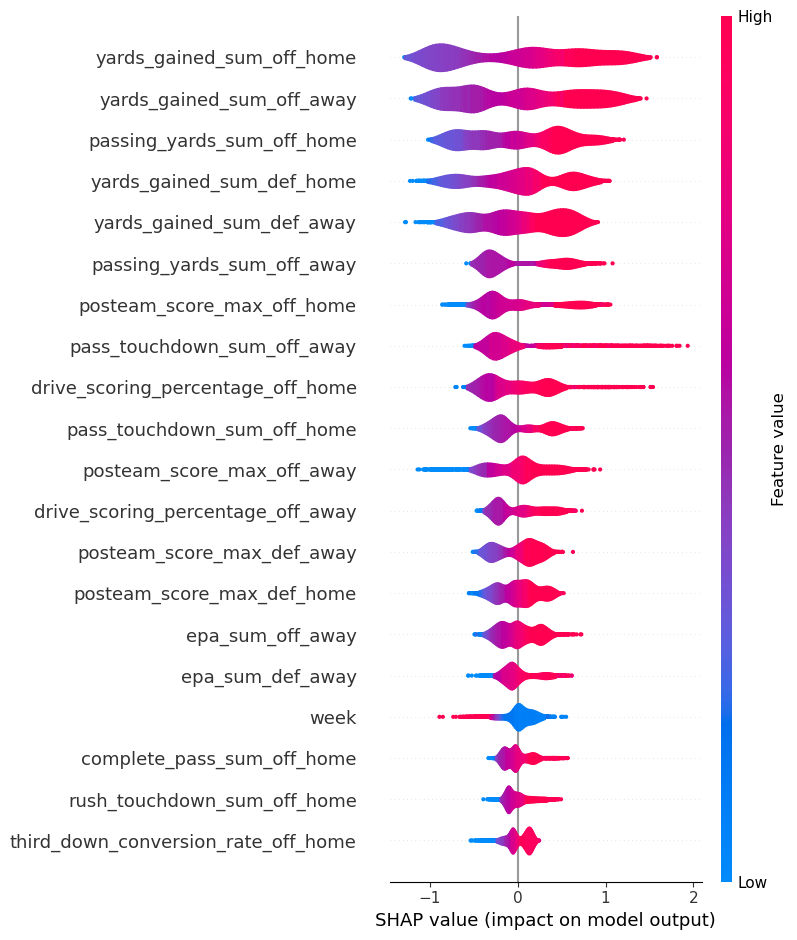

Week 1 : 0.8000 (4/5)
Week 2 : 0.4286 (3/7)
Week 3 : 0.7500 (6/8)
Week 4 : 0.5000 (3/6)
Week 5 : 1.0000 (4/4)
Week 6 : 0.4000 (2/5)
Week 7 : 0.8333 (5/6)
Week 8 : 0.2000 (1/5)
Week 9 : 0.8333 (5/6)
Week 10: 0.4000 (2/5)
Week 11: 0.2000 (1/5)
Week 12: 0.5000 (4/8)
Week 13: 0.8333 (5/6)
Week 14: 0.2500 (1/4)
Week 15: 0.3333 (2/6)

Season Accuracy: 0.5581 (48/86)


In [10]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
test_seasons = [2024]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-27 13:46:03,316] A new study created in memory with name: no-name-11ab4dd1-3d06-4e63-beed-ffa571490aa2
[I 2024-12-27 13:46:09,366] Trial 0 finished with value: 3.26410664553575 and parameters: {'max_depth': 1, 'subsample': 0.736487893227521, 'colsample_bytree': 0.8423082413272552, 'learning_rate': 0.002843641712834413, 'reg_alpha': 0.0, 'reg_lambda': 0.1}. Best is trial 0 with value: 3.26410664553575.
[I 2024-12-27 13:46:10,919] Trial 1 finished with value: 2.4515139542092195 and parameters: {'max_depth': 4, 'subsample': 0.9732766067737205, 'colsample_bytree': 0.5985762236458898, 'learning_rate': 0.07693340131969882, 'reg_alpha': 0.5, 'reg_lambda': 0.0}. Best is trial 1 with value: 2.4515139542092195.
[I 2024-12-27 13:46:12,598] Trial 2 finished with value: 2.4480144135505424 and parameters: {'max_depth': 1, 'subsample': 0.5465429574714412, 'colsample_bytree': 0.6754928905755833, 'learning_rate': 0.08564568322215164, 'reg_alpha': 0.1, 'reg_lambda': 0.5}. Best is trial 2 with

Best Optuna parameters: {'max_depth': 4, 'subsample': 0.520911740622824, 'colsample_bytree': 0.8197456621216112, 'learning_rate': 0.029754027926488708, 'reg_alpha': 1.0, 'reg_lambda': 0.0}
Best Optuna score: 2.3912318122167653



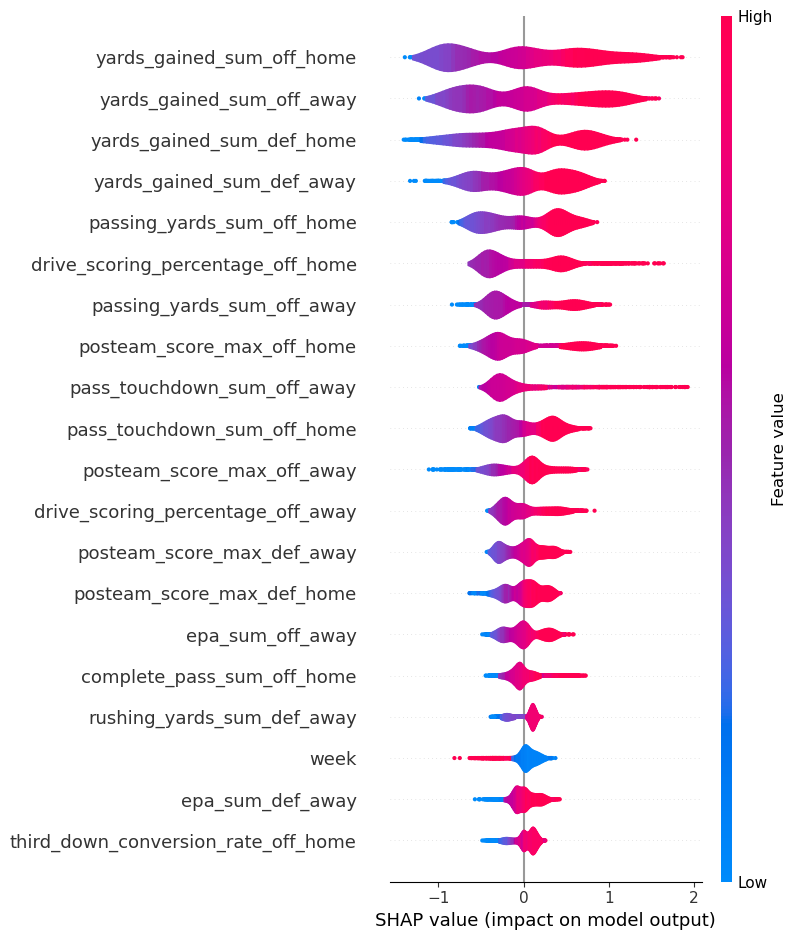

Week 1 : 0.4000 (2/5)
Week 2 : 0.3750 (3/8)
Week 3 : 0.6667 (2/3)
Week 4 : 0.0000 (0/3)
Week 5 : 0.8000 (4/5)
Week 6 : 0.5000 (3/6)
Week 7 : 0.3333 (1/3)
Week 8 : 0.3333 (2/6)
Week 9 : 0.5000 (4/8)
Week 10: 0.1667 (1/6)
Week 11: 0.2857 (2/7)
Week 12: 0.3636 (4/11)
Week 13: 0.4000 (2/5)
Week 14: 1.0000 (6/6)
Week 15: 0.2857 (2/7)
Week 16: 0.5714 (4/7)
Week 17: 0.5200 (13/25)

Season Accuracy: 0.4545 (55/121)


In [11]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
test_seasons = [2023]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-27 13:59:36,560] A new study created in memory with name: no-name-c27120f8-0c5b-4d84-96d6-605816acaceb
[I 2024-12-27 13:59:39,088] Trial 0 finished with value: 2.4248436906993627 and parameters: {'max_depth': 2, 'subsample': 0.9375347887010252, 'colsample_bytree': 0.6649276695768928, 'learning_rate': 0.04319103250656385, 'reg_alpha': 0.5, 'reg_lambda': 1.0}. Best is trial 0 with value: 2.4248436906993627.
[I 2024-12-27 13:59:44,868] Trial 1 finished with value: 2.4108840320810656 and parameters: {'max_depth': 2, 'subsample': 0.5112714677894556, 'colsample_bytree': 0.7669445281758747, 'learning_rate': 0.013555914623125501, 'reg_alpha': 0.5, 'reg_lambda': 0.0}. Best is trial 1 with value: 2.4108840320810656.
[I 2024-12-27 13:59:47,216] Trial 2 finished with value: 2.41166312491235 and parameters: {'max_depth': 4, 'subsample': 0.5856658288196235, 'colsample_bytree': 0.9955745584091547, 'learning_rate': 0.053242182577093726, 'reg_alpha': 1.0, 'reg_lambda': 0.1}. Best is trial 1 

Best Optuna parameters: {'max_depth': 4, 'subsample': 0.5360878049047423, 'colsample_bytree': 0.8721947515078482, 'learning_rate': 0.018762216417677776, 'reg_alpha': 0.5, 'reg_lambda': 0.5}
Best Optuna score: 2.379723191546734



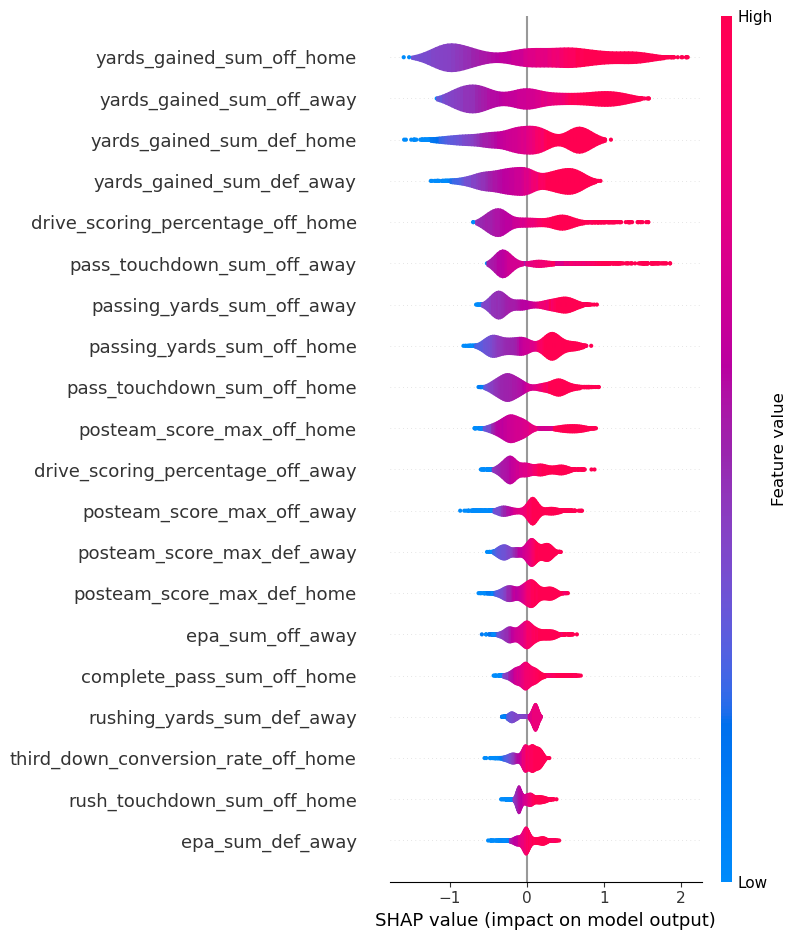

Week 1 : 0.3333 (3/9)
Week 2 : 0.5000 (3/6)
Week 3 : 0.5714 (4/7)
Week 4 : 0.6000 (3/5)
Week 5 : 0.5000 (3/6)
Week 6 : 0.6000 (3/5)
Week 7 : 0.4000 (2/5)
Week 8 : 0.0000 (0/5)
Week 9 : 0.2500 (1/4)
Week 10: 0.2500 (1/4)
Week 11: 0.8000 (4/5)
Week 12: 0.1667 (1/6)
Week 13: 0.2857 (2/7)
Week 14: 0.4286 (3/7)
Week 15: 0.5556 (5/9)
Week 16: 0.4545 (5/11)
Week 17: 0.6316 (12/19)

Season Accuracy: 0.4583 (55/120)


In [12]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
test_seasons = [2022]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-27 14:07:27,292] A new study created in memory with name: no-name-eddd0da0-1ad0-4160-b9cb-a88299be85a7
[I 2024-12-27 14:07:28,573] Trial 0 finished with value: 2.452973615658393 and parameters: {'max_depth': 3, 'subsample': 0.8248373204929913, 'colsample_bytree': 0.6988045610251448, 'learning_rate': 0.09007094961745302, 'reg_alpha': 0.1, 'reg_lambda': 0.0}. Best is trial 0 with value: 2.452973615658393.
[I 2024-12-27 14:07:30,475] Trial 1 finished with value: 2.4458313815166552 and parameters: {'max_depth': 2, 'subsample': 0.9106928538526013, 'colsample_bytree': 0.8479862962348425, 'learning_rate': 0.053802979645360606, 'reg_alpha': 0.0, 'reg_lambda': 0.0}. Best is trial 1 with value: 2.4458313815166552.
[I 2024-12-27 14:07:42,028] Trial 2 finished with value: 2.4549393647435886 and parameters: {'max_depth': 4, 'subsample': 0.6954542267053527, 'colsample_bytree': 0.5533335531907548, 'learning_rate': 0.004662041187890409, 'reg_alpha': 1.0, 'reg_lambda': 0.1}. Best is trial 1 

Best Optuna parameters: {'max_depth': 5, 'subsample': 0.5084388514421081, 'colsample_bytree': 0.5491546037065012, 'learning_rate': 0.011330044941574134, 'reg_alpha': 0.1, 'reg_lambda': 0.1}
Best Optuna score: 2.4033593377922076



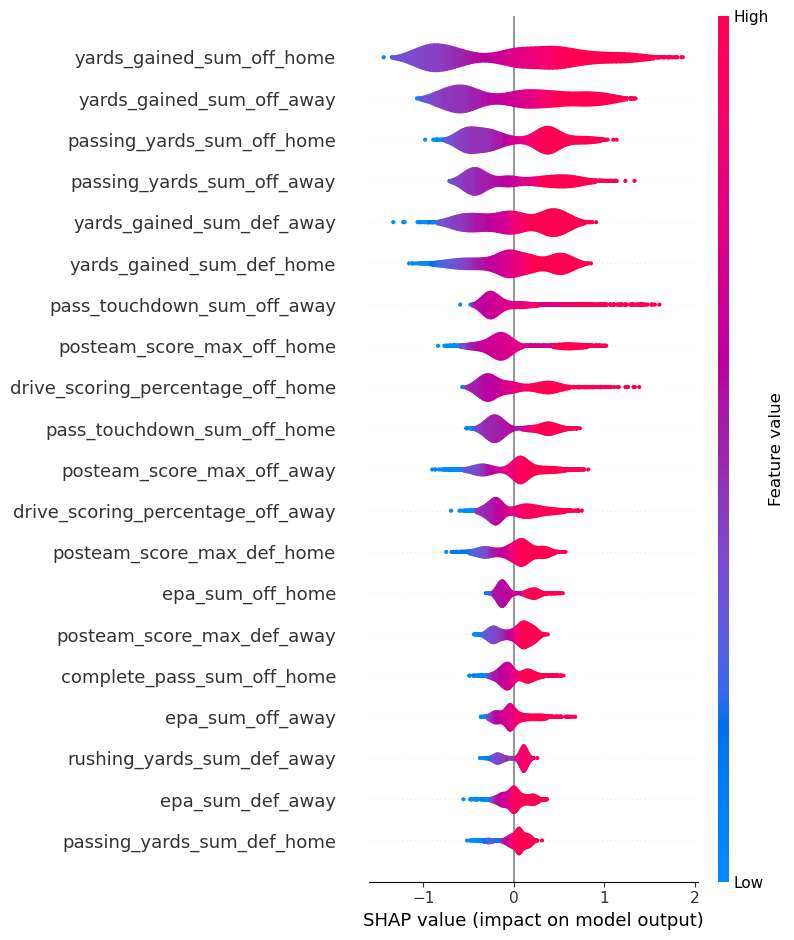

Week 1 : 0.5000 (3/6)
Week 2 : 0.4286 (3/7)
Week 3 : 0.4444 (4/9)
Week 4 : 0.3333 (2/6)
Week 5 : 0.4286 (3/7)
Week 6 : 0.2857 (2/7)
Week 7 : 0.5000 (3/6)
Week 8 : 0.2000 (1/5)
Week 9 : 0.4000 (2/5)
Week 10: 0.7500 (3/4)
Week 11: 0.7500 (3/4)
Week 12: 0.8000 (4/5)
Week 13: 0.2857 (2/7)
Week 14: 0.4286 (3/7)
Week 15: 0.6250 (5/8)
Week 16: 0.7000 (7/10)
Week 17: 0.6087 (14/23)

Season Accuracy: 0.5079 (64/126)


In [13]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
test_seasons = [2021]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-27 14:17:52,164] A new study created in memory with name: no-name-2abe54e6-8af1-407f-b209-418840ffff02
[I 2024-12-27 14:17:54,382] Trial 0 finished with value: 2.3906062546693496 and parameters: {'max_depth': 2, 'subsample': 0.9818828283373464, 'colsample_bytree': 0.5529533226252301, 'learning_rate': 0.040629654516073685, 'reg_alpha': 0.5, 'reg_lambda': 1.0}. Best is trial 0 with value: 2.3906062546693496.
[I 2024-12-27 14:17:55,712] Trial 1 finished with value: 2.4089277500177864 and parameters: {'max_depth': 3, 'subsample': 0.6659465057258976, 'colsample_bytree': 0.7166490933885061, 'learning_rate': 0.07257326689989245, 'reg_alpha': 1.0, 'reg_lambda': 5.0}. Best is trial 0 with value: 2.3906062546693496.
[I 2024-12-27 14:17:59,580] Trial 2 finished with value: 2.4060935404935995 and parameters: {'max_depth': 1, 'subsample': 0.8023044809707232, 'colsample_bytree': 0.9435048174597894, 'learning_rate': 0.02688544996026974, 'reg_alpha': 1.0, 'reg_lambda': 0.0}. Best is trial 0

Best Optuna parameters: {'max_depth': 5, 'subsample': 0.5527962034067628, 'colsample_bytree': 0.5974094531906134, 'learning_rate': 0.010178387386457696, 'reg_alpha': 0.1, 'reg_lambda': 0.0}
Best Optuna score: 2.3378542219842737



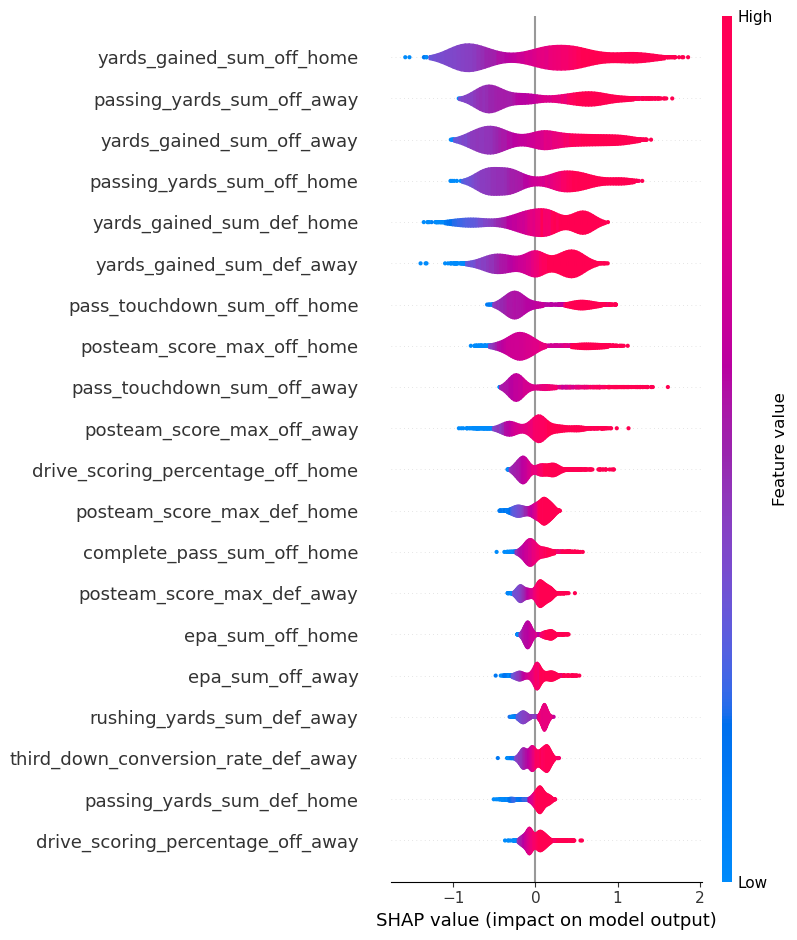

Week 1 : 0.5556 (5/9)
Week 2 : 0.5000 (4/8)
Week 3 : 0.5385 (7/13)
Week 4 : 0.5000 (5/10)
Week 5 : 0.5000 (5/10)
Week 6 : 0.5556 (5/9)
Week 7 : 0.4286 (3/7)
Week 8 : 0.5000 (5/10)
Week 9 : 0.5000 (4/8)
Week 10: 0.5000 (3/6)
Week 11: 0.4444 (4/9)
Week 12: 0.5455 (6/11)
Week 13: 0.3333 (2/6)
Week 14: 0.6250 (5/8)
Week 15: 0.3571 (5/14)
Week 16: 0.2857 (2/7)
Week 17: 0.4286 (3/7)
Week 18: 0.8571 (6/7)

Season Accuracy: 0.4969 (79/159)


In [14]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
test_seasons = [2020]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-27 14:26:19,507] A new study created in memory with name: no-name-b302c438-3da5-424f-866f-85b5283e0cf7
[I 2024-12-27 14:26:21,011] Trial 0 finished with value: 2.336701505883602 and parameters: {'max_depth': 3, 'subsample': 0.8895468166200281, 'colsample_bytree': 0.6889230171023888, 'learning_rate': 0.07049430635448285, 'reg_alpha': 1.0, 'reg_lambda': 0.1}. Best is trial 0 with value: 2.336701505883602.
[I 2024-12-27 14:26:25,236] Trial 1 finished with value: 2.42114088172668 and parameters: {'max_depth': 1, 'subsample': 0.9519733096774247, 'colsample_bytree': 0.7361983474634803, 'learning_rate': 0.020705854447426883, 'reg_alpha': 1.0, 'reg_lambda': 0.0}. Best is trial 0 with value: 2.336701505883602.
[I 2024-12-27 14:26:27,410] Trial 2 finished with value: 2.3424289682215296 and parameters: {'max_depth': 2, 'subsample': 0.6841552934017241, 'colsample_bytree': 0.8599417118797377, 'learning_rate': 0.038312357964059025, 'reg_alpha': 0.0, 'reg_lambda': 0.1}. Best is trial 0 wit

Best Optuna parameters: {'max_depth': 4, 'subsample': 0.5915396880984521, 'colsample_bytree': 0.8020332810765998, 'learning_rate': 0.019852106279794605, 'reg_alpha': 0.0, 'reg_lambda': 0.0}
Best Optuna score: 2.2875180558355033



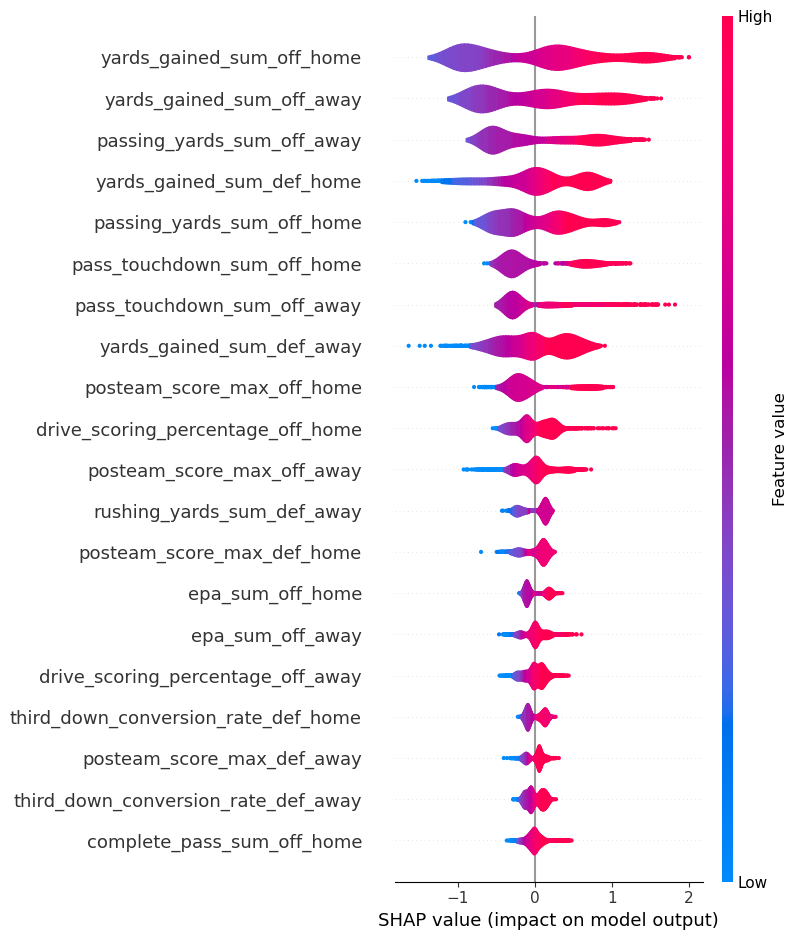

Week 1 : 0.4286 (3/7)
Week 2 : 0.6000 (6/10)
Week 3 : 0.5714 (4/7)
Week 4 : 0.3333 (2/6)
Week 5 : 0.6000 (3/5)
Week 6 : 0.2500 (1/4)
Week 7 : 0.6250 (5/8)
Week 8 : 0.5714 (8/14)
Week 9 : 0.5000 (3/6)
Week 10: 0.5000 (3/6)
Week 11: 0.8333 (5/6)
Week 12: 0.2857 (2/7)
Week 13: 0.6250 (5/8)
Week 14: 0.7143 (5/7)
Week 15: 0.5000 (5/10)
Week 16: 0.5714 (4/7)
Week 17: 0.7500 (6/8)
Week 18: 0.5000 (3/6)

Season Accuracy: 0.5530 (73/132)


In [15]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
test_seasons = [2019]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-27 14:34:34,867] A new study created in memory with name: no-name-fa99294e-0249-4f97-a7f2-0266d43f45f3


[I 2024-12-27 14:34:38,638] Trial 0 finished with value: 2.4100700723625055 and parameters: {'max_depth': 1, 'subsample': 0.6538157696174021, 'colsample_bytree': 0.5621416828968897, 'learning_rate': 0.02049674027918762, 'reg_alpha': 0.0, 'reg_lambda': 5.0}. Best is trial 0 with value: 2.4100700723625055.
[I 2024-12-27 14:34:42,058] Trial 1 finished with value: 2.291398975983973 and parameters: {'max_depth': 4, 'subsample': 0.5385364463665924, 'colsample_bytree': 0.8230821730132619, 'learning_rate': 0.025651972809668282, 'reg_alpha': 0.1, 'reg_lambda': 0.0}. Best is trial 1 with value: 2.291398975983973.
[I 2024-12-27 14:34:43,310] Trial 2 finished with value: 2.400465952753842 and parameters: {'max_depth': 1, 'subsample': 0.7630118527937823, 'colsample_bytree': 0.6785294328617335, 'learning_rate': 0.09445170697576369, 'reg_alpha': 0.1, 'reg_lambda': 5.0}. Best is trial 1 with value: 2.291398975983973.
[I 2024-12-27 14:34:44,667] Trial 3 finished with value: 2.345781549918532 and parame

Best Optuna parameters: {'max_depth': 4, 'subsample': 0.5385364463665924, 'colsample_bytree': 0.8230821730132619, 'learning_rate': 0.025651972809668282, 'reg_alpha': 0.1, 'reg_lambda': 0.0}
Best Optuna score: 2.291398975983973



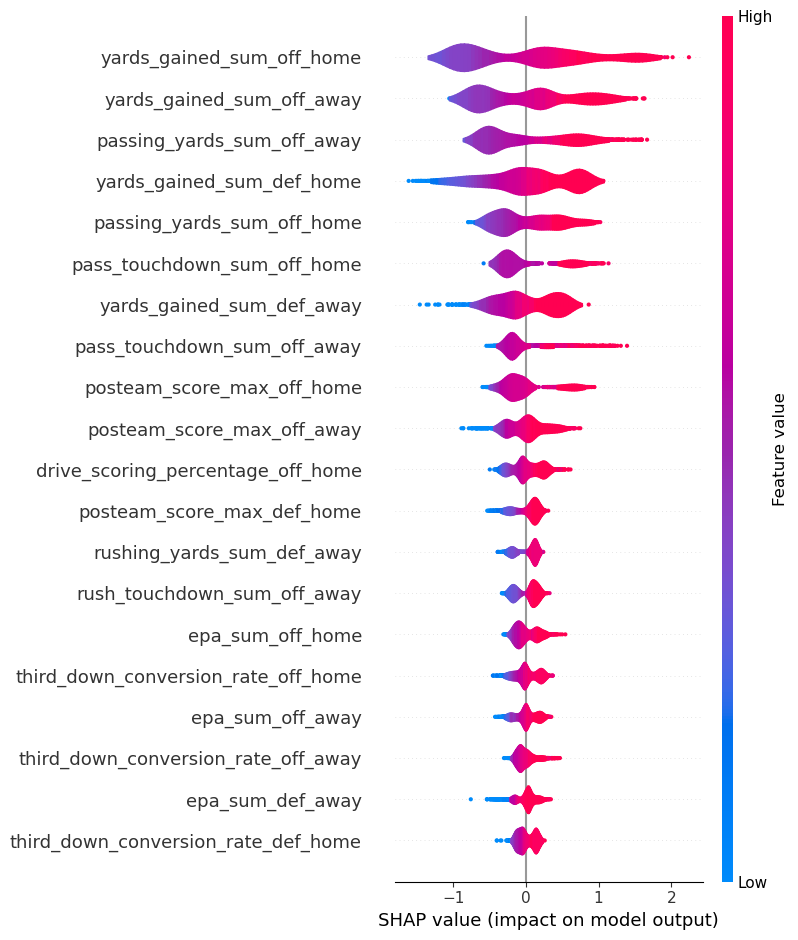

Week 1 : 0.5455 (6/11)
Week 2 : 0.5000 (4/8)
Week 3 : 0.2222 (2/9)
Week 4 : 0.6250 (5/8)
Week 5 : 0.2857 (2/7)
Week 6 : 0.4000 (2/5)
Week 7 : 0.6667 (4/6)
Week 8 : 0.6667 (4/6)
Week 9 : 0.3333 (2/6)
Week 10: 1.0000 (1/1)
Week 11: 0.5000 (5/10)
Week 12: 0.8571 (6/7)
Week 13: 0.3750 (3/8)
Week 14: 0.6250 (5/8)
Week 15: 0.4286 (3/7)
Week 16: 0.1250 (1/8)
Week 17: 0.5000 (6/12)
Week 18: 0.6667 (4/6)

Season Accuracy: 0.4887 (65/133)


In [16]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017]
test_seasons = [2018]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)